In [41]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
data = fetch_california_housing()
df = pd.DataFrame(data.data,columns=data.feature_names)
df["target"]= data.target

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
X = df.drop("target",axis=1)
y=df["target"]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [13]:
model = LinearRegression()

In [14]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [44]:
y_pred = model.predict(X_test)

In [45]:
mae = mean_absolute_error(y_test,y_pred)
r_square = np.sqrt(mae)

In [46]:
print(mae)
print(r_square)

0.5250103014936683
0.724575945980591


Here mae 0.52 means 1 is equal to $100,000. So, it is 52000 + or - prediction
R^2 is 72% which means the feature model only successfuly considers 72% variance and 28% is missing

In [47]:
print(model.score(X_train, y_train))

0.6062115991006275


In [48]:
model.score(X_test, y_test)

0.6018848029990963

In [49]:
coefficients=pd.DataFrame({"features":X.columns,"Coefficient":model.coef_})

In [53]:
coefficients = coefficients.sort_values(by="Coefficient", key=abs, ascending=False)
coefficients.head()

,features,Coefficient
3,AveBedrms,0.756762
0,MedInc,0.441529
7,Longitude,-0.435250
6,Latitude,-0.424235
2,AveRooms,-0.116650


Avgbedroom leads the price with median income as high income equals high price homes then location

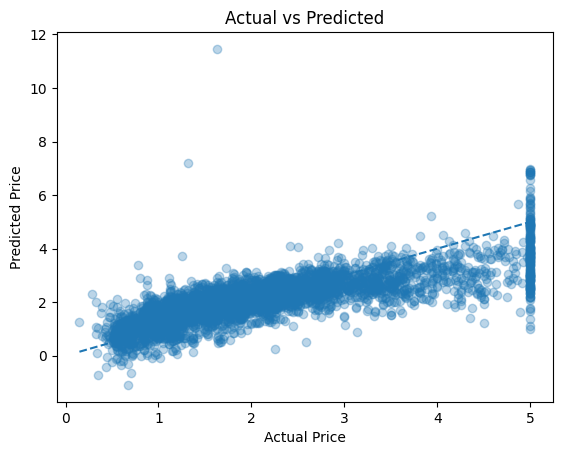

In [56]:
plt.scatter(y_test, y_pred, alpha=0.3)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

This model predicts the output with +- $52k target prediction and 72% r2 with 28% features cannot be captured